In [9]:
import pandas as pd
import numpy as np

np.random.seed(42)

n_samples = 1000

rpm = np.random.normal(loc=1500, scale=300, size=n_samples)
vibration = np.random.normal(loc=5.0, scale=1.5, size=n_samples)
pressure = np.random.normal(loc=30, scale=5, size=n_samples)

modes = ['Eco', 'Standard', 'High-Speed']
machine_mode = np.random.choice(modes, size=n_samples)

temperature = 50 + (rpm * 0.02) + (vibration * 2.5) + (pressure * 0.8) + np.random.normal(loc=0, scale=5, size=n_samples)

probability_defect = 1 / (1 + np.exp(-( (temperature-130)*0.1 + (vibration-6)*0.5 )))
defective = np.random.binomial(1, probability_defect)

df = pd.DataFrame({
    'RPM': rpm,
    'Vibration': vibration,
    'Pressure': pressure,
    'Machine_Mode': machine_mode,
    'Temperature': temperature,
    'Defective': defective
})

df.to_csv('factory_sensor_data.csv', index=False)
df.head()


,RPM,Vibration,Pressure,Machine_Mode,Temperature,Defective
0,1649.014246,7.099033,26.624109,Standard,116.824880,0
1,1458.520710,6.386951,29.277407,Standard,117.638526,0
2,1694.306561,5.089446,26.037900,Standard,108.669638,0
3,1956.908957,4.029595,28.460192,Eco,116.504790,0
4,1429.753988,6.047335,20.531927,High-Speed,115.509885,0


## Task 1: Simple Linear Regression


Simple Linear Regression MSE: 55.10


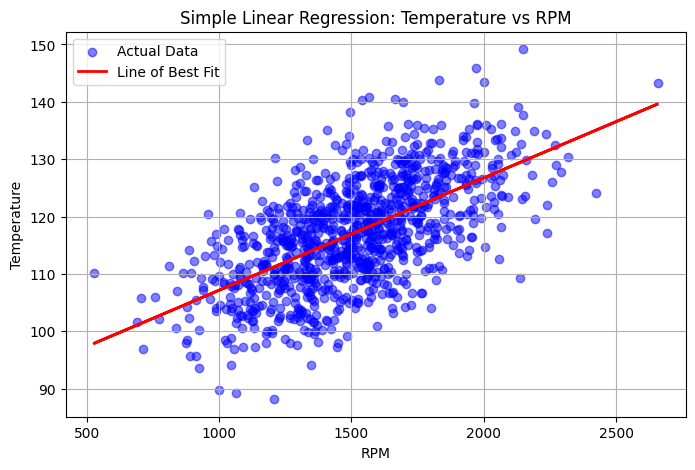

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

df = pd.read_csv('factory_sensor_data.csv')

X_simple = df[['RPM']]
y = df['Temperature']

model_simple = LinearRegression()
model_simple.fit(X_simple, y)
y_pred_simple = model_simple.predict(X_simple)

mse_simple = mean_squared_error(y, y_pred_simple)
print(f"Simple Linear Regression MSE: {mse_simple:.2f}")

plt.figure(figsize=(8, 5))
plt.scatter(X_simple, y, color='blue', alpha=0.5, label='Actual Data')
plt.plot(X_simple, y_pred_simple, color='red', linewidth=2, label='Line of Best Fit')
plt.title('Simple Linear Regression: Temperature vs RPM')
plt.xlabel('RPM')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.show()


## Task 2: Multivariable Regression


In [11]:

X_multi = df[['RPM', 'Vibration', 'Pressure']]

model_multi = LinearRegression()
model_multi.fit(X_multi, y)
y_pred_multi = model_multi.predict(X_multi)

mse_multi = mean_squared_error(y, y_pred_multi)
print(f"Multivariable Regression MSE: {mse_multi:.2f}")
print(f"Simple Regression MSE (from Task 1): {mse_simple:.2f}")
print(f"MSE Improvement: {mse_simple - mse_multi:.2f}")


Multivariable Regression MSE: 23.36
Simple Regression MSE (from Task 1): 55.10
MSE Improvement: 31.73


## Task 3: Save Model


In [12]:
import joblib

model_filename = 'multivariable_temp_model.joblib'
joblib.dump(model_multi, model_filename)
print(f"Model successfully saved to {model_filename}")


Model successfully saved to multivariable_temp_model.joblib


In [13]:

loaded_model = joblib.load(model_filename)

new_reading = pd.DataFrame({'RPM': [1600], 'Vibration': [4.2], 'Pressure': [32.0]})
predicted_temp = loaded_model.predict(new_reading)

print(f"Predicted Temperature for new reading: {predicted_temp[0]:.2f}")


Predicted Temperature for new reading: 118.38


## Task 4: One-Hot Encoding


In [14]:

df_encoded = pd.get_dummies(df, columns=['Machine_Mode'], drop_first=True, dtype=int)

print("Original columns:", list(df.columns))
print("Encoded columns:", list(df_encoded.columns))
df_encoded.head()


Original columns: ['RPM', 'Vibration', 'Pressure', 'Machine_Mode', 'Temperature', 'Defective']
Encoded columns: ['RPM', 'Vibration', 'Pressure', 'Temperature', 'Defective', 'Machine_Mode_High-Speed', 'Machine_Mode_Standard']


,RPM,Vibration,Pressure,Temperature,Defective,Machine_Mode_High-Speed,Machine_Mode_Standard
0,1649.014246,7.099033,26.624109,116.824880,0,0,1
1,1458.520710,6.386951,29.277407,117.638526,0,0,1
2,1694.306561,5.089446,26.037900,108.669638,0,0,1
3,1956.908957,4.029595,28.460192,116.504790,0,0,0
4,1429.753988,6.047335,20.531927,115.509885,0,1,0


## Task 5: Train-Test Split

In [15]:
from sklearn.model_selection import train_test_split


X_full = df_encoded.drop(columns=['Temperature', 'Defective'])
y_full = df_encoded['Temperature']

X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.20, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

model_full = LinearRegression()
model_full.fit(X_train, y_train)


train_predictions = model_full.predict(X_train)
test_predictions = model_full.predict(X_test)

mse_train = mean_squared_error(y_train, train_predictions)
mse_test = mean_squared_error(y_test, test_predictions)

print(f"MSE on Training Set: {mse_train:.2f}")
print(f"MSE on Testing Set: {mse_test:.2f}")


Training data shape: (800, 5)
Testing data shape: (200, 5)
MSE on Training Set: 23.12
MSE on Testing Set: 24.34


## Task 6: Logistic Regression

Confusion Matrix:
[[154   8]
 [ 25  13]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.95      0.90       162
           1       0.62      0.34      0.44        38

    accuracy                           0.83       200
   macro avg       0.74      0.65      0.67       200
weighted avg       0.81      0.83      0.82       200



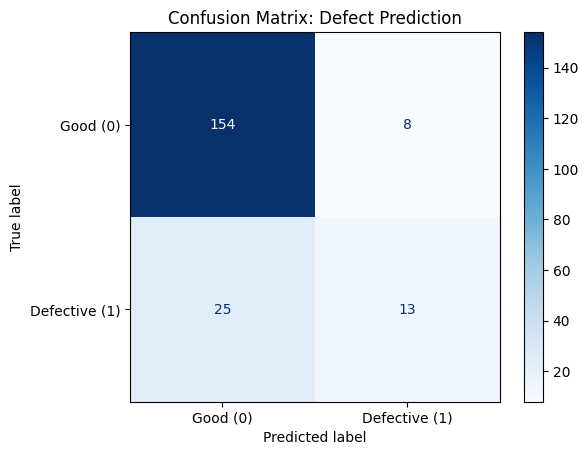

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

X_clf = df_encoded.drop(columns=['Defective'])
y_clf = df_encoded['Defective']


X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.20, random_state=42)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_clf, y_train_clf)

y_pred_clf = clf.predict(X_test_clf)

cm = confusion_matrix(y_test_clf, y_pred_clf)
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good (0)', 'Defective (1)'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Defect Prediction')
plt.show()
